# 📊 Regresión Logística Binaria — Dogs API

Predicción de la probabilidad de que una raza sea **hipoalergénica** usando variables derivadas del dataset normalizado de Dogs.

- **Variable objetivo**: `hipoalergenico` (1 = Sí, 0 = No)
- **Modelo**: `LogisticRegression` (scikit-learn)
- **Validación**: 3 splits (80/20 · 60/40 · 70/30) con `stratify=y`

Este notebook imita el flujo de `regresion_logistica_clima.ipynb`, adaptado a `dogs_normalized.csv`.


## I. Configuración Inicial — Importaciones y Estilo Visual


In [4]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ Librerías importadas correctamente')
print(f'   pandas   {pd.__version__}')
print(f'   numpy    {np.__version__}')
print(f'   seaborn  {sns.__version__}')


✅ Librerías importadas correctamente
   pandas   2.3.3
   numpy    2.4.3
   seaborn  0.13.2


## II. Carga de Datos desde CSV

Se usa el dataset normalizado generado por el pipeline de Dogs.

Requisito: debe existir `../data/dogs_normalized.csv` (si no existe, genera el dataset con el ETL antes de ejecutar el notebook).


In [5]:
# ── CELDA 2: Carga CSV ─────────────────────────────────────────────────────────
from pathlib import Path
# Nota: en Jupyter, las rutas relativas dependen del working directory del kernel.
# Por eso probamos rutas típicas para que funcione si ejecutas desde:
# - data-dogs/notebook/  -> ../data/...
# - data-dogs/           -> data/...
CANDIDATES = [
    Path('../data/dogs_normalized.csv'),
    Path('data/dogs_normalized.csv'),
]
DATA_PATH = next((p for p in CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'No se encontró dogs_normalized.csv. Probé: '
        + ', '.join(str(p) for p in CANDIDATES)
        + '\\nAsegúrate de generar el dataset (ETL) dentro de data-dogs/data/.'
    )
df_raw = pd.read_csv(DATA_PATH)
print(f'✅ Datos cargados: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f"\n📌 Ruta usada: {DATA_PATH.resolve()}")
print(f"\nColumnas disponibles:\n{df_raw.columns.tolist()}")
df_raw.head()


✅ Datos cargados: 283 filas × 11 columnas

📌 Ruta usada: /home/molina211/ETL-MineríaDeDatos/Corte_3/Semana15-RegresiónLogística-Binario/data-dogs/data/dogs_normalized.csv

Columnas disponibles:
['raza', 'vida_min', 'vida_max', 'vida_promedio', 'peso_macho_max', 'peso_hembra_max', 'peso_promedio', 'categoria_peso', 'diferencia_sexual_peso', 'hipoalergenico', 'fecha_extraccion']


,raza,vida_min,vida_max,vida_promedio,peso_macho_max,peso_hembra_max,peso_promedio,categoria_peso,diferencia_sexual_peso,hipoalergenico,fecha_extraccion
0,Affenpinscher,14,16,15.0,5,5,5.0,Muy pequeño,0,True,2026-03-26T12:16:51.082919
1,Afghan Hound,12,14,13.0,27,25,26.0,Mediano,2,False,2026-03-26T12:16:51.082954
2,Airedale Terrier,12,14,13.0,23,20,21.5,Mediano,3,False,2026-03-26T12:16:51.082964
3,Akita,10,12,11.0,60,50,55.0,Gigante,10,False,2026-03-26T12:16:51.082972
4,Alaskan Klee Kai,12,15,13.5,7,7,7.0,Muy pequeño,0,False,2026-03-26T12:16:51.082980


In [6]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print('=' * 55)
print('VALIDACIÓN DEL DATASET (DOGS)')
print('=' * 55)

print('\n📋 Tipos de datos y valores nulos:')
print(df_raw.dtypes.to_frame('dtype').join(df_raw.isnull().sum().to_frame('nulos')))

# Target en 0/1
hipo = df_raw['hipoalergenico'].astype(str).str.lower().map({'true': 1, 'false': 0})

print('\n🎯 Balance de la variable objetivo (hipoalergenico):')
counts = hipo.value_counts(dropna=False)
pct = hipo.value_counts(normalize=True, dropna=False) * 100
print(f"   Clase 1 (hipoalergénico): {int(counts.get(1,0)):,}  ({float(pct.get(1,0.0)):.1f}%)")
print(f"   Clase 0 (no hipo):        {int(counts.get(0,0)):,}  ({float(pct.get(0,0.0)):.1f}%)")

print('\n📦 Distribución categoria_peso:')
print(df_raw['categoria_peso'].value_counts().to_string())


VALIDACIÓN DEL DATASET (DOGS)

📋 Tipos de datos y valores nulos:
                          dtype  nulos
raza                     object      0
vida_min                  int64      0
vida_max                  int64      0
vida_promedio           float64      0
peso_macho_max            int64      0
peso_hembra_max           int64      0
peso_promedio           float64      0
categoria_peso           object      0
diferencia_sexual_peso    int64      0
hipoalergenico             bool      0
fecha_extraccion         object      0

🎯 Balance de la variable objetivo (hipoalergenico):
   Clase 1 (hipoalergénico): 13  (4.6%)
   Clase 0 (no hipo):        270  (95.4%)

📦 Distribución categoria_peso:
categoria_peso
Grande         78
Muy pequeño    62
Mediano        54
Pequeño        47
Gigante        42


## III. Preprocesamiento de Datos

Pasos (análogos al notebook de clima):
1. Features de fecha (`mes`, `dia_semana`).
2. Relleno de nulos (mediana) para numéricas.
3. One-Hot Encoding para `categoria_peso`.
4. Escalado con `StandardScaler` (recomendado para modelos lineales).


In [7]:
# ── CELDA 4: Preprocesamiento ─────────────────────────────────────────────────
df = df_raw.copy()

# 1) Fecha -> mes, dia_semana
# (si falla, queda NaT)
df['fecha_extraccion'] = pd.to_datetime(df['fecha_extraccion'], errors='coerce')
df['mes'] = df['fecha_extraccion'].dt.month
df['dia_semana'] = df['fecha_extraccion'].dt.dayofweek

# 2) Target 0/1
# (CSV trae True/False como texto)
df['hipoalergenico'] = df['hipoalergenico'].astype(str).str.lower().map({'true': 1, 'false': 0})

# 3) Numéricas + log(peso)
df['peso_promedio'] = pd.to_numeric(df['peso_promedio'], errors='coerce')
df['vida_promedio'] = pd.to_numeric(df['vida_promedio'], errors='coerce')
df['diferencia_sexual_peso'] = pd.to_numeric(df['diferencia_sexual_peso'], errors='coerce')
df['log_peso'] = np.log(df['peso_promedio'].clip(lower=1e-6))

num_cols = ['vida_promedio', 'peso_promedio', 'log_peso', 'diferencia_sexual_peso', 'mes', 'dia_semana']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 4) One-Hot de categoria_peso
# drop_first=True evita redundancia perfecta
df = pd.get_dummies(df, columns=['categoria_peso'], drop_first=True, dtype=int)

# 5) Definir X e y
# Excluimos identificadores y columnas redundantes
_drop = ['raza', 'fecha_extraccion', 'hipoalergenico', 'vida_min', 'vida_max',
         'peso_macho_max', 'peso_hembra_max']
drop_cols = [c for c in _drop if c in df.columns]

X_raw = df.drop(columns=drop_cols)
y = df['hipoalergenico']

print('✅ Preprocesamiento completado')
print(f'   Shape X_raw: {X_raw.shape}')
print(f"   Clases en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")

# 6) Escalado: solo columnas numéricas (las dummies ya están en 0/1)
num_in_X = [c for c in num_cols if c in X_raw.columns]
cat_in_X = [c for c in X_raw.columns if c not in num_in_X]

scaler = StandardScaler()
X_scaled = X_raw.copy()
X_scaled[num_in_X] = scaler.fit_transform(X_raw[num_in_X])

print('✅ Escalado completado (StandardScaler)')
print(f'   Num cols escaladas: {num_in_X}')
print(f'   Cat cols (sin escalar): {len(cat_in_X)}')


✅ Preprocesamiento completado
   Shape X_raw: (283, 10)
   Clases en y → 0: 270  |  1: 13
✅ Escalado completado (StandardScaler)
   Num cols escaladas: ['vida_promedio', 'peso_promedio', 'log_peso', 'diferencia_sexual_peso', 'mes', 'dia_semana']
   Cat cols (sin escalar): 4


## IV. Entrenamiento y Evaluación — Tres Splits


In [8]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────────────────────

def entrenar_evaluar(X, y, test_size, random_state=42, nombre='Split'):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        solver='lbfgs',
    )
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre': nombre,
        'train_size': len(X_train),
        'test_size': len(X_test),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'fpr': fpr,
        'tpr': tpr,
        'y_test': y_test,
        'y_pred': y_pred,
        'modelo': modelo,
        'X_cols': list(X.columns),
    }

print('✅ Función entrenar_evaluar() definida correctamente')
print("   · LogisticRegression — class_weight='balanced' + StandardScaler")


✅ Función entrenar_evaluar() definida correctamente
   · LogisticRegression — class_weight='balanced' + StandardScaler


In [9]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────
resultados = [
    entrenar_evaluar(X_scaled, y, test_size=0.20, nombre='Split 80/20'),
    entrenar_evaluar(X_scaled, y, test_size=0.40, nombre='Split 60/40'),
    entrenar_evaluar(X_scaled, y, test_size=0.30, nombre='Split 70/30'),
]

print('=' * 65)
print(f"{'MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA BINARIA (DOGS)':^65}")
print('=' * 65)
header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print('-' * 65)
for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )
print('=' * 65)


   MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA BINARIA (DOGS)    
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20       226       57  0.5965  0.0833  0.6667  0.1481  0.7315
Split 60/40       169      114  0.7193  0.0645  0.4000  0.1111  0.7037
Split 70/30       198       85  0.6235  0.0625  0.5000  0.1111  0.6852


## V. Visualizaciones


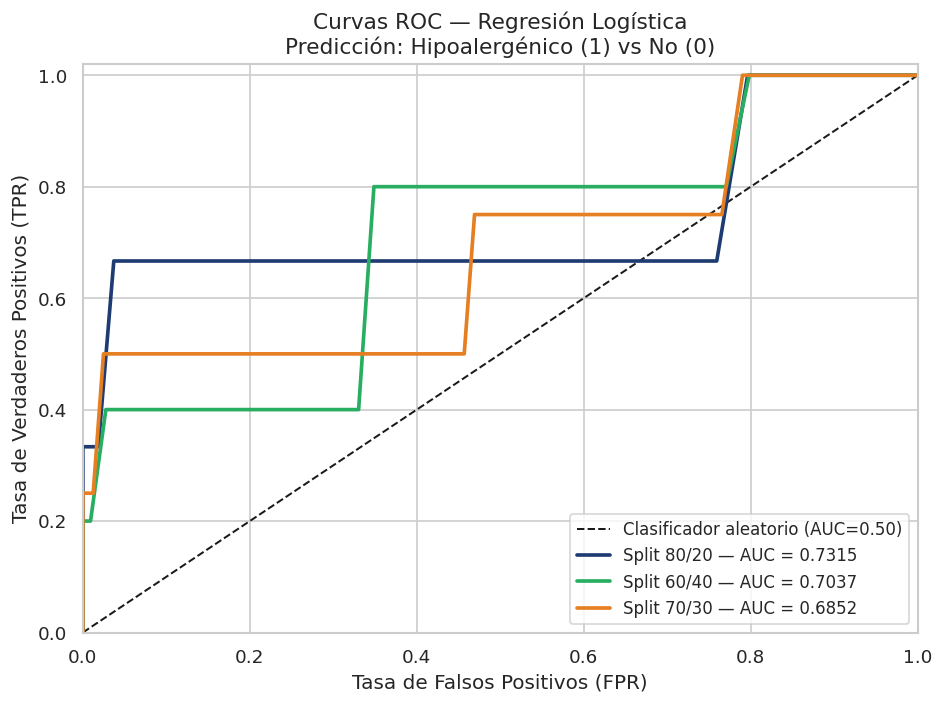

✅ Curvas ROC guardadas en data/graficas/roc_logistica_dogs.png


In [10]:
# ── CELDA 7: Curvas ROC comparativas ─────────────────────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r, color in zip(resultados, COLORS):
    ax.plot(r['fpr'], r['tpr'], color=color, lw=2.2,
            label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}")

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Regresión Logística\nPredicción: Hipoalergénico (1) vs No (0)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('../data/graficas/roc_logistica_dogs.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Curvas ROC guardadas en data/graficas/roc_logistica_dogs.png')


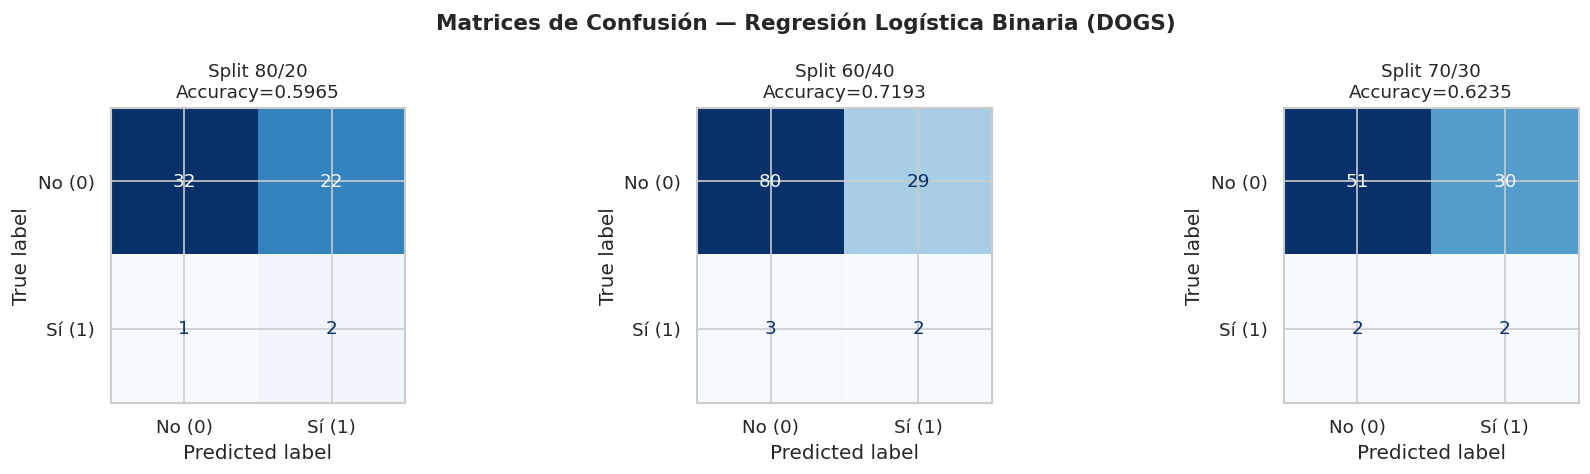

✅ Matrices de confusión guardadas en data/graficas/confusion_logistica_dogs.png


In [11]:
# ── CELDA 8: Matrices de Confusión (3 splits) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Regresión Logística Binaria (DOGS)', fontsize=13, fontweight='bold')

for ax, r, color in zip(axes, resultados, COLORS):
    cm = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Sí (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}", fontsize=11)

plt.tight_layout()
plt.savefig('../data/graficas/confusion_logistica_dogs.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Matrices de confusión guardadas en data/graficas/confusion_logistica_dogs.png')


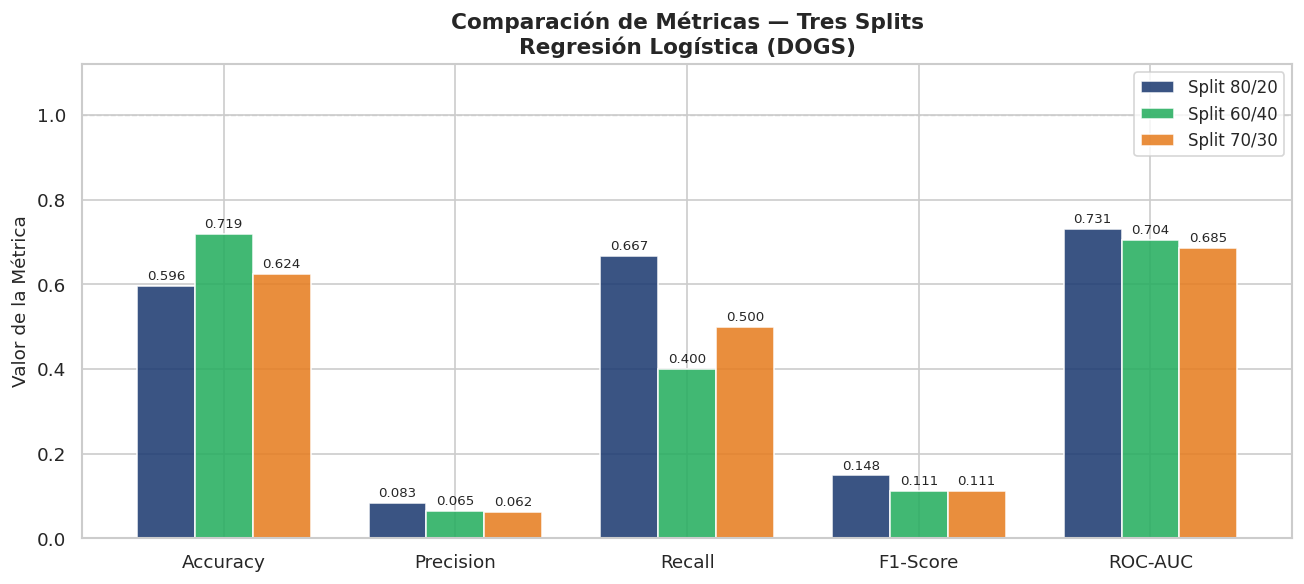

✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_logistica_dogs.png


In [12]:
# ── CELDA 9: Gráfico comparativo de métricas ─────────────────────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]
    bars = ax.bar(x + i * width, vals, width, label=r['nombre'], color=color, alpha=0.88)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Tres Splits\nRegresión Logística (DOGS)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('../data/graficas/metricas_comparativas_logistica_dogs.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_logistica_dogs.png')


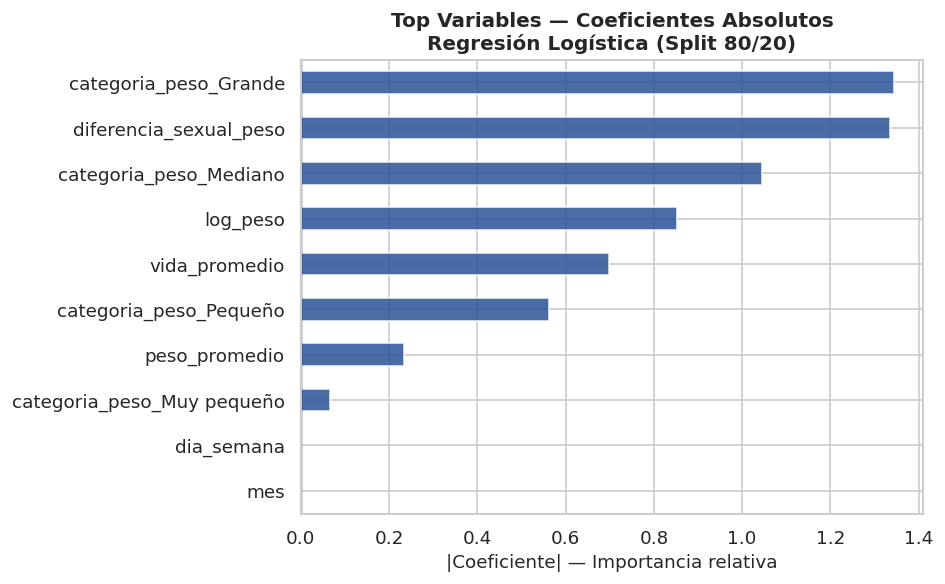

✅ Importancia de coeficientes guardada en data/graficas/coeficientes_logistica_dogs.png


In [13]:
# ── CELDA 10: Importancia de coeficientes (Split 80/20) ──────────────────────
modelo_ref = resultados[0]['modelo']
coefs = pd.Series(modelo_ref.coef_[0], index=X_scaled.columns)
coefs_ord = coefs.abs().sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
coefs_ord.plot(kind='barh', ax=ax, color='#2a5298', alpha=0.85)
ax.set_xlabel('|Coeficiente| — Importancia relativa', fontsize=11)
ax.set_title('Top Variables — Coeficientes Absolutos\nRegresión Logística (Split 80/20)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_logistica_dogs.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Importancia de coeficientes guardada en data/graficas/coeficientes_logistica_dogs.png')


## VI. Tabla Final de Métricas y Conclusiones


In [14]:
# ── CELDA 11: DataFrame resumen de métricas ───────────────────────────────────
resumen = pd.DataFrame([{
    'Split': r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba': r['test_size'],
    'Accuracy': round(r['accuracy'], 4),
    'Precision': round(r['precision'], 4),
    'Recall': round(r['recall'], 4),
    'F1-Score': round(r['f1'], 4),
    'ROC-AUC': round(r['roc_auc'], 4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print('=' * 65)
print(f"{'TABLA FINAL DE MÉTRICAS':^65}")
print('=' * 65)
display(
    resumen.style
        .background_gradient(cmap='Greens', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
        .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
        .set_caption('Regresión Logística Binaria — Predicción: Hipoalergénico (Dogs API)')
)


                     TABLA FINAL DE MÉTRICAS                     


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,226,57,0.5965,0.0833,0.6667,0.1481,0.7315
Split 60/40,169,114,0.7193,0.0645,0.4000,0.1111,0.7037
Split 70/30,198,85,0.6235,0.0625,0.5000,0.1111,0.6852


## VII. Conclusiones

- La regresión logística entrega **probabilidades** (0–1) y luego clases con un umbral (default 0.5).
- Con desbalance fuerte (pocos `hipoalergenico=1`), Accuracy puede ser engañosa: prioriza **F1** y **ROC-AUC**.
- `class_weight='balanced'` aumenta el peso de la clase minoritaria y suele mejorar Recall/F1.
- Los coeficientes (en valor absoluto) sugieren qué variables influyen más en la decisión del modelo.
